In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad

In [2]:
import os
os.chdir("/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/")
print(os.getcwd())

from utils import (
    # VISUALIZATION
    rolling_kde_heatmap_with_turns,
    display_turns_colored_by_kde,
    compute_graph_perplexity,
    correlation_heatmap,
    # HELPERS
    compute_dominance_per_spk,
    compute_significance,
    expand_multiple_ppl_by_token,
    remove_match_prefix_ppl,
    average_ppl_per_turn,
    assign_words_to_bins
)

/u/sebono/conversational_dominance/notebooks/information_exchange_labelling


[nltk_data] Downloading package punkt to /u/sebono/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /u/sebono/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

#model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"
model_id="gpt2-large"
device = "cuda:0"
perplexity_func = "p1"

if "gpt2" in model_id:
    #model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
if "Llama" in model_id:
    #model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'

### Analyzing Candor

In [4]:
import pandas as pd
import re
import numpy as np

candor_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/CANDOR/conversations.csv")
candor_df.head()

,file_name,file_content
0,7595d874-c1cb-4aef-918f-3c81f3a84324,<SPK0> this is Yeah. Mhm. Mhm. Yeah. Yeah. Mot...
1,66768810-879d-4e2f-b5f5-ecc67d298104,<SPK0> Uh huh uh huh. Yeah. <SPK1> Yeah. All r...
2,dc3d0ae4-8d20-4d1d-8e0c-82c85a79b26e,<SPK1> Yeah. Right. Mhm. Mhm. Mhm. Okay. Yeah....
3,fb50ccf7-1a5a-4d80-b4f0-d5d1a1fd1135,<SPK0> Hi there and move away. <SPK1> mm. <SPK...
4,73c201ef-8c32-43d4-b642-dcedf4aa5c7f,<SPK0> Yeah. Okay. Yeah. Mhm. Yeah. Mhm Uh huh...


In [5]:
file_name = "66768810-879d-4e2f-b5f5-ecc67d298104"
dialog = candor_df[candor_df['file_name']==file_name]["file_content"][1]

In [6]:
import re 
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape
assert len(matches) == len(dialog_lines)

Token indices sequence length is longer than the specified maximum sequence length for this model (11296 > 1024). Running this sequence through the model will result in indexing errors


In [7]:
all_data = pd.DataFrame({})
for p_name in ['p1','p2','p3']:
    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/CANDOR_{p_name}_{model_id}/dominance_scores_{file_name}.pkl'
    with open(file_name_sample, 'rb') as f:
        all_data[f"{p_name}"] = pickle.load(f)[file_name]

In [8]:
token_list

[tensor([   27,  4303,    42,    15,    29, 28574, 24926, 21480, 24926,    13,
          9425,    13,   220]),
 tensor([  27, 4303,   42,   16,   29, 9425,   13, 1439,  826,  220]),
 tensor([  27, 4303,   42,   15,   29, 4599,   13, 1374,  338,  220]),
 tensor([  27, 4303,   42,   16,   29,  922,  220]),
 tensor([  27, 4303,   42,   15,   29,  340, 1016,   11,  220]),
 tensor([  27, 4303,   42,   16,   29,  922,   13, 1406,  356,  821, 8066,  466,
          428,  329,  546, 1679, 2431,  314, 4724,   13,  220]),
 tensor([  27, 4303,   42,   15,   29,  331,  538,   11,  220]),
 tensor([   27,  4303,    42,    16,    29, 16805,   477,   826,   314,  1183,
           923,   314,  1101,   287, 14493,    11,  6405,   734,  3988,  3598,
           290,  5193,  6733,  6912, 26053,  4336,    13, 21039,  8152,   257,
          1256,  1141,  9283,  1622,    13,   337, 23940,    13,   220]),
 tensor([   27,  4303,    42,    15,    29, 35109,   220]),
 tensor([  27, 4303,   42,   16,   29, 9425,   

In [9]:
all_data

,p1,p2,p3
0,NaN,NaN,5.263611
1,7.840308,7.840308,4.970372
2,5.805719,6.823014,3.663251
3,8.343096,7.329708,2.204863
4,1.388582,5.844426,1.569036
...,...,...,...
11291,0.000908,0.048530,2.749101
11292,0.584073,0.185137,2.886573
11293,0.000947,0.125732,2.642044
11294,10.326426,1.838270,2.469830


In [10]:
all_data.bfill(inplace=True)

filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_ppl)

filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_ppl)

filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=0)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_ppl)

assert len(filtered_tokens_p3) == len(token_list)
assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)
assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

all_data_filtered = pd.DataFrame({"p1":filtered_ppl_p1,"p2":filtered_ppl_p2, "p3":filtered_ppl_p3 })

/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/utils.py:550: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



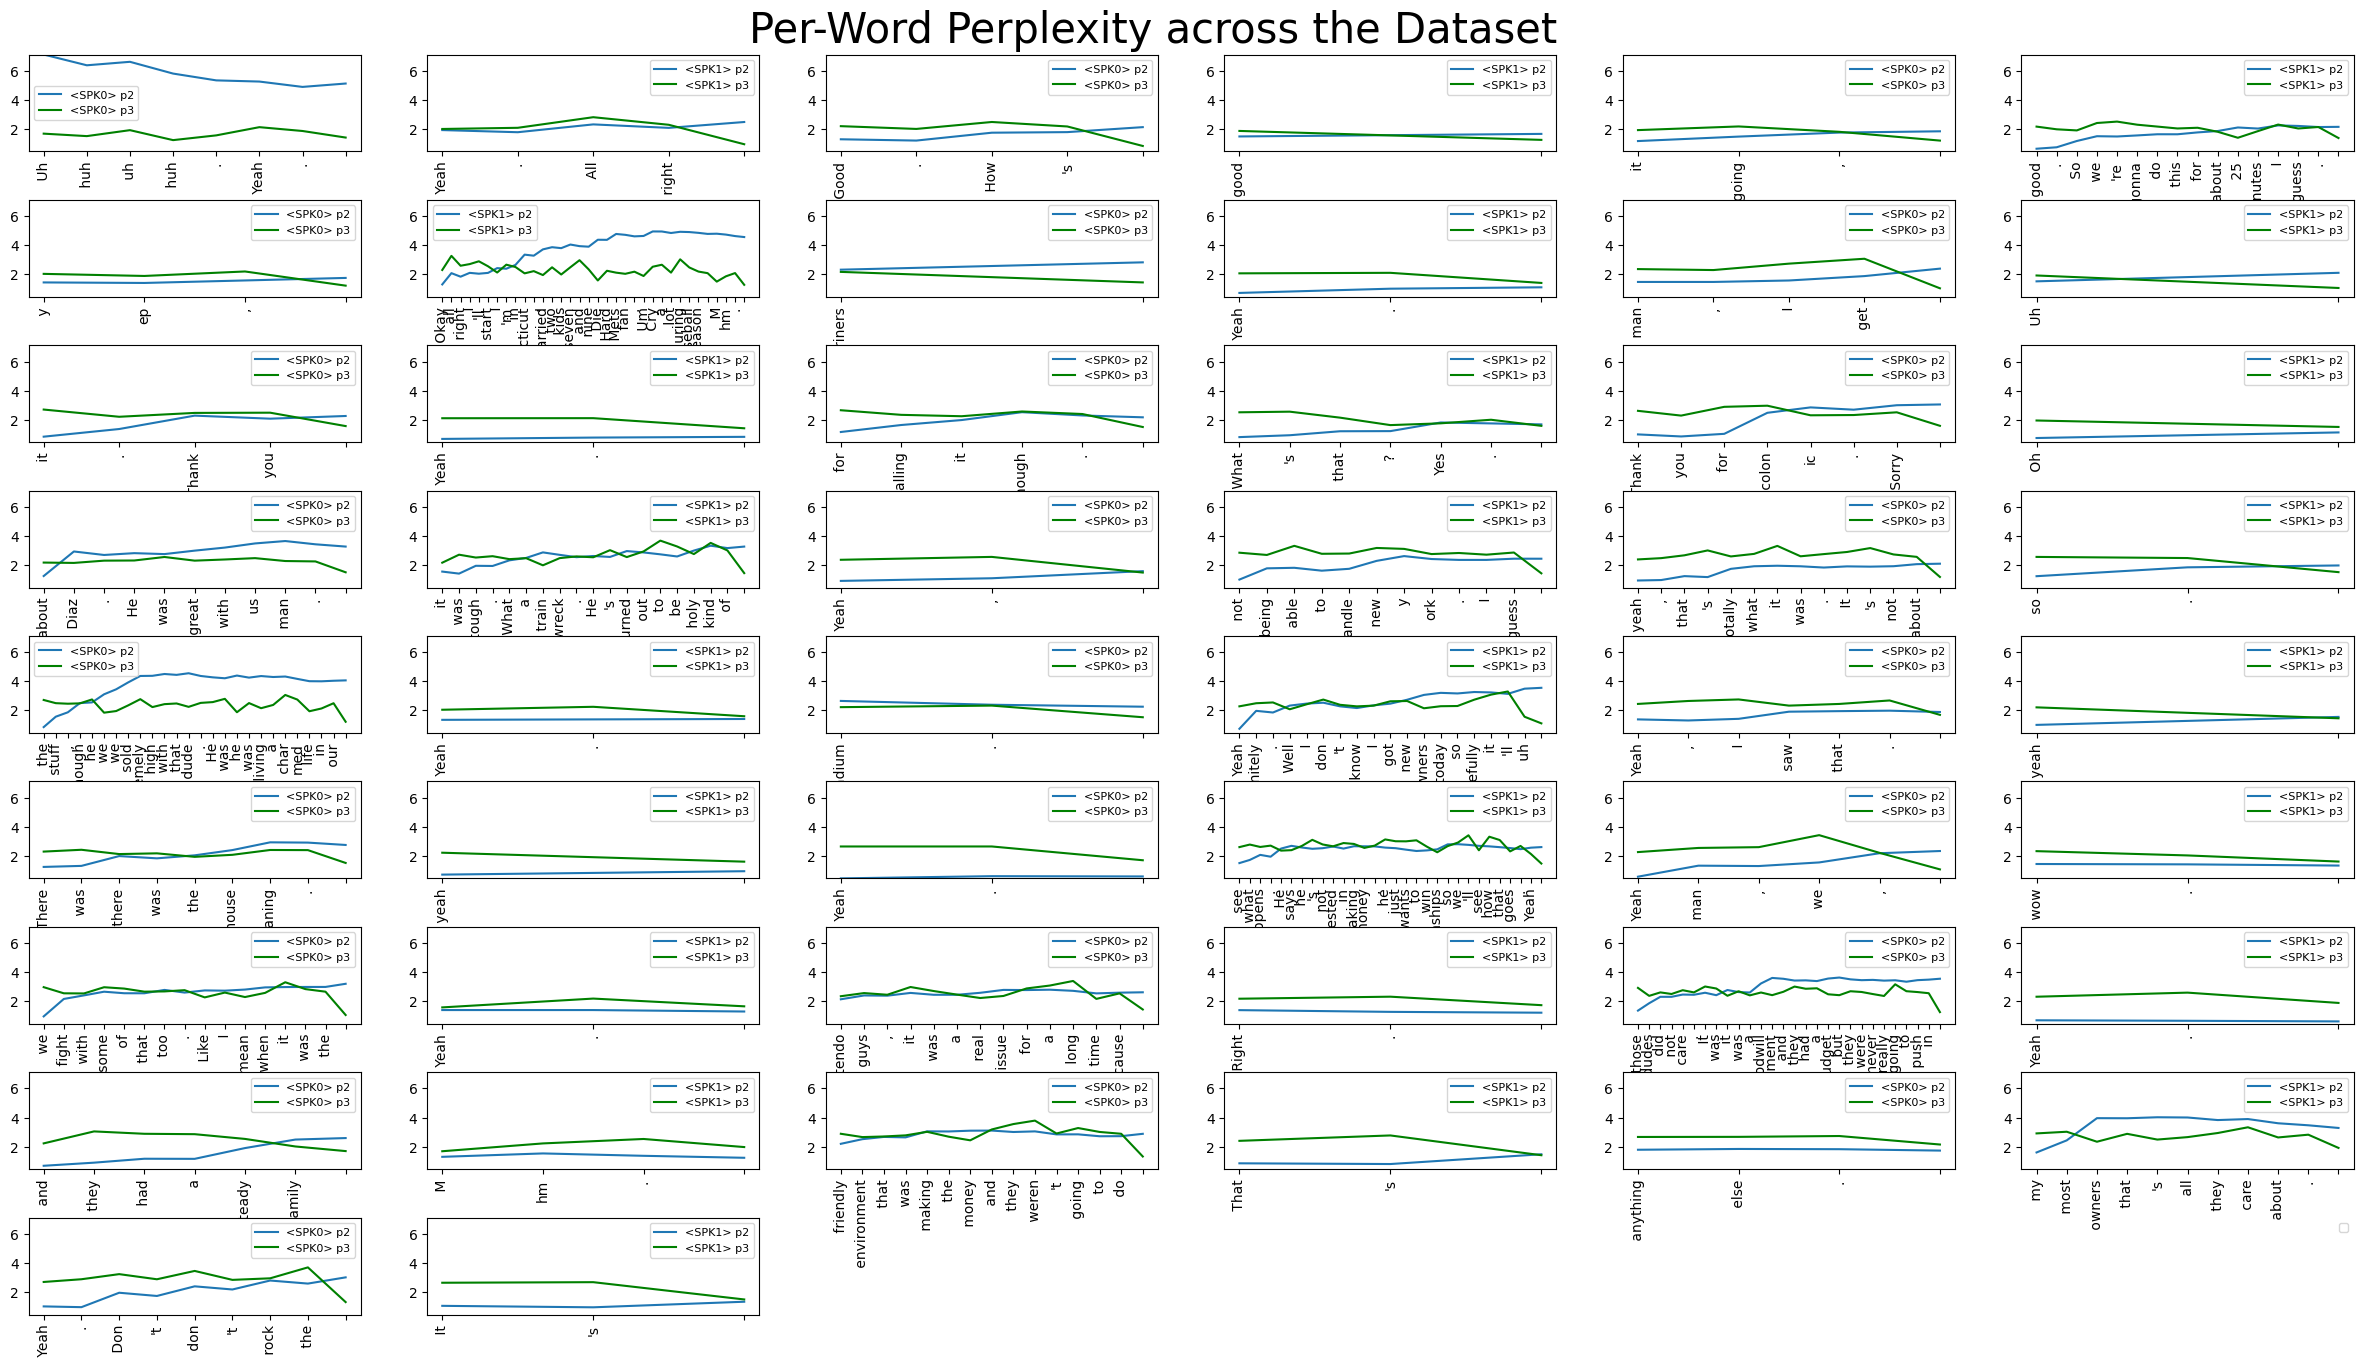

In [11]:
last=50
end = np.cumsum([len(l) for l in filtered_tokens_p1[:last]])[-1]
compute_graph_perplexity(tokenizer, filtered_tokens_p2[:last], filtered_ppl_p2[:end], filtered_ppl_p3[:end], filtered_matches_p2[:last], {"p1":"p2","p2":"p3"}, answers=None)

In [12]:
all_data_filtered

,p1,p2,p3
0,12.220145,7.119569,1.672976
1,2.671987,6.378305,1.503223
2,8.057991,6.618260,1.912879
3,0.137734,5.808195,1.227036
4,1.596331,5.340210,1.553795
...,...,...,...
6931,10.241486,2.232013,2.812908
6932,0.666368,2.025230,2.292244
6933,0.731787,1.869058,1.572470
6934,10.326426,1.838270,2.469830


In [13]:
baselined_ppls_p1_spk = compute_dominance_per_spk(filtered_ppl_p1, filtered_tokens_p1, filtered_matches_p1, tokenizer)
baselined_ppls_p2_spk = compute_dominance_per_spk(filtered_ppl_p2, filtered_tokens_p2, filtered_matches_p2, tokenizer)
baselined_ppls_p3_spk = compute_dominance_per_spk(filtered_ppl_p3, filtered_tokens_p3, filtered_matches_p3, tokenizer)

In [14]:
rows, nested = compute_significance(baselined_ppls_p1_spk, list(np.unique(filtered_matches_p3)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK0>,<SPK1>,3626,3310,6.303235e-02,2.003185e-06,2.003185e-06
1,Mann-Whitney U,<SPK0>,<SPK1>,3626,3310,6.436466e+06,1.717428e-07,1.717428e-07
2,T-test,<SPK0>,<SPK1>,3626,3310,4.887806e+00,1.042676e-06,1.042676e-06


In [15]:
rows, nested = compute_significance(baselined_ppls_p2_spk, list(np.unique(filtered_matches_p3)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK0>,<SPK1>,3626,3310,6.323898e-02,0.000002,0.000002
1,Mann-Whitney U,<SPK0>,<SPK1>,3626,3310,6.260111e+06,0.001869,0.001869
2,T-test,<SPK0>,<SPK1>,3626,3310,2.717980e+00,0.006585,0.006585


In [16]:
rows, nested = compute_significance(baselined_ppls_p3_spk, list(np.unique(filtered_matches_p3)), adjust_p="fdr_bh")

# If you want a DataFrame:
import pandas as pd
df = pd.DataFrame(rows).sort_values(["test","p_value"])
df

,test,spk_i,spk_j,n_i,n_j,statistic,p_value,p_value_adj
0,KS,<SPK0>,<SPK1>,3626,3310,3.420413e-02,0.033819,0.033819
1,Mann-Whitney U,<SPK0>,<SPK1>,3626,3310,6.178246e+06,0.033375,0.033375
2,T-test,<SPK0>,<SPK1>,3626,3310,1.623340e+00,0.104562,0.104562


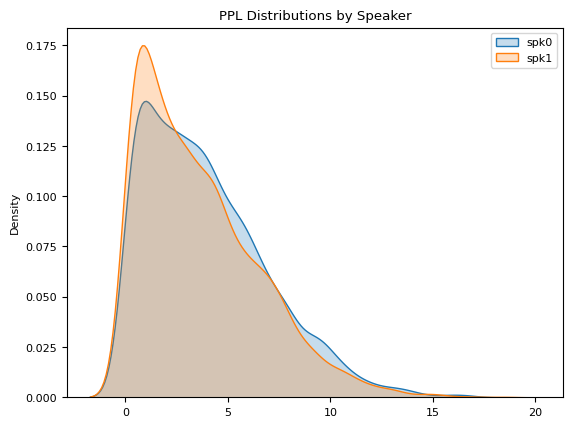

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(baselined_ppls_p1_spk[f"<SPK0>"], label="spk0", fill=True)
sns.kdeplot(baselined_ppls_p1_spk[f"<SPK1>"], label="spk1", fill=True)
plt.title("PPL Distributions by Speaker")
plt.legend()
plt.show()

In [18]:
all_data_filtered

,p1,p2,p3
0,12.220145,7.119569,1.672976
1,2.671987,6.378305,1.503223
2,8.057991,6.618260,1.912879
3,0.137734,5.808195,1.227036
4,1.596331,5.340210,1.553795
...,...,...,...
6931,10.241486,2.232013,2.812908
6932,0.666368,2.025230,2.292244
6933,0.731787,1.869058,1.572470
6934,10.326426,1.838270,2.469830


In [19]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered)

In [20]:
fig_p

In [21]:
fig_corr

### Labels

In [22]:
directory = "/u/sebono/conversational_dominance/data/external/CANDOR/transcript_audiophile/"
directory_file = directory + f"{file_name}.csv"
transcript_audiophile = pd.read_csv(directory_file).iloc[1:]
transcript_audiophile.head()

,turn_id,speaker,start,stop,utterance,interval,delta,questions,end_question,overlap,n_words
1,1,5d10d808156091001a74639e,52.84,54.94,Yeah. All right,21.88,2.10,0,False,False,3
2,2,5977e3867412f8000194e1fe,54.94,56.05,Good. How's,0.00,1.11,0,False,False,3
3,3,5d10d808156091001a74639e,56.04,57.35,good,-0.01,1.31,0,False,True,1
4,4,5977e3867412f8000194e1fe,56.05,56.65,"it going,",-1.30,0.60,0,False,True,2
5,5,5d10d808156091001a74639e,57.36,62.66,good. So we're gonna do this for about 25 minu...,0.71,5.30,0,False,False,14


In [23]:
path_annotations = "/u/sebono/conversational_dominance/data/processed/CANDOR/affective_labels/"
annotation_file = path_annotations + f"{file_name}.csv"
affective_labels = pd.read_csv(annotation_file)
affective_labels.iloc[:800]

,timedelta,user_id,f0,intensity,jitter,log_energy,mfcc_0,mfcc_1,mfcc_10,mfcc_11,...,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile,is_speaking
0,00:00:00,5977e3867412f8000194e1fe,NaN,0.000000,NaN,-103.610379,-504.34180,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,00:00:00,5d10d808156091001a74639e,NaN,0.000000,NaN,-133.722991,-513.47810,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,00:00:01,5977e3867412f8000194e1fe,NaN,0.000000,NaN,-103.610379,-504.34180,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,00:00:01,5d10d808156091001a74639e,NaN,0.000000,NaN,-133.722991,-513.47810,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,00:00:02,5977e3867412f8000194e1fe,415.063238,0.858936,16.728910,-39.724186,-345.58438,99.048965,-1.215374,-1.785356,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,00:06:37,5d10d808156091001a74639e,NaN,0.766461,NaN,-92.590676,-513.47810,NaN,NaN,NaN,...,0.097883,0.021147,0.065490,0.071600,0.347592,0.154505,0.044696,0.197086,0.0,False
796,00:06:38,5977e3867412f8000194e1fe,121.155180,0.886378,2.190840,-26.501100,-320.78415,149.748720,-10.225272,-17.097597,...,0.011118,0.040799,0.008804,0.131375,0.245928,0.202147,0.174440,0.185390,1.0,True
797,00:06:38,5d10d808156091001a74639e,NaN,0.703726,NaN,-92.930473,-513.47810,NaN,NaN,NaN,...,0.127271,0.027074,0.050340,0.045374,0.264864,0.290518,0.058155,0.136404,0.0,False
798,00:06:39,5977e3867412f8000194e1fe,108.451428,0.593794,0.579612,-27.414990,-335.35547,126.742096,-11.881174,-15.006159,...,0.010666,0.009344,0.020536,0.158196,0.312521,0.059708,0.115954,0.313075,1.0,True


In [24]:
cols = list(affective_labels.keys())[5:]

In [25]:
transcript_audiophile["tokens"] = filtered_tokens_p1[1:]

In [26]:
transcript_audiophile

,turn_id,speaker,start,stop,utterance,interval,delta,questions,end_question,overlap,n_words,tokens
1,1,5d10d808156091001a74639e,52.84,54.94,Yeah. All right,21.88,2.10,0,False,False,3,"[tensor(9425), tensor(13), tensor(1439), tenso..."
2,2,5977e3867412f8000194e1fe,54.94,56.05,Good. How's,0.00,1.11,0,False,False,3,"[tensor(4599), tensor(13), tensor(1374), tenso..."
3,3,5d10d808156091001a74639e,56.04,57.35,good,-0.01,1.31,0,False,True,1,"[tensor(922), tensor(220)]"
4,4,5977e3867412f8000194e1fe,56.05,56.65,"it going,",-1.30,0.60,0,False,True,2,"[tensor(340), tensor(1016), tensor(11), tensor..."
5,5,5d10d808156091001a74639e,57.36,62.66,good. So we're gonna do this for about 25 minu...,0.71,5.30,0,False,False,14,"[tensor(922), tensor(13), tensor(1406), tensor..."
...,...,...,...,...,...,...,...,...,...,...,...,...
867,867,5d10d808156091001a74639e,1665.64,1666.86,All right. Good,0.08,1.22,0,False,False,3,"[tensor(1439), tensor(826), tensor(13), tensor..."
868,868,5977e3867412f8000194e1fe,1666.74,1666.88,Good,-0.12,0.14,0,False,True,1,"[tensor(4599), tensor(220)]"
869,869,5d10d808156091001a74639e,1666.86,1667.40,talk,-0.02,0.54,0,False,True,1,"[tensor(1561), tensor(220)]"
870,870,5977e3867412f8000194e1fe,1666.88,1667.36,talkative.,-0.52,0.48,0,False,True,1,"[tensor(1561), tensor(876), tensor(13), tensor..."


In [27]:
speakers = np.unique(transcript_audiophile["speaker"])

In [28]:
affective_labels["timedelta"] = pd.to_timedelta(affective_labels["timedelta"])
affective_labels["time_bin"] = affective_labels["timedelta"].dt.total_seconds().astype(int)

In [29]:
cols_affect = np.asarray(list(affective_labels.keys())[-11:-2])

In [30]:
affective_labels_spk0 = affective_labels[affective_labels['user_id']==speakers[0]][cols + ['time_bin']].reset_index(drop=True)
affective_labels_spk1 = affective_labels[affective_labels['user_id']==speakers[1]][cols + ['time_bin']].reset_index(drop=True)
assert affective_labels_spk1.shape == affective_labels_spk0.shape

In [31]:
bins_dfs = assign_words_to_bins(transcript_audiophile, tokenizer)

In [32]:
combined_df_spk0 = affective_labels_spk0.merge(bins_dfs[speakers[0]], on="time_bin", how="inner")
combined_df_spk1 = affective_labels_spk1.merge(bins_dfs[speakers[1]], on="time_bin", how="inner")

In [33]:
all_data_filtered

,p1,p2,p3
0,12.220145,7.119569,1.672976
1,2.671987,6.378305,1.503223
2,8.057991,6.618260,1.912879
3,0.137734,5.808195,1.227036
4,1.596331,5.340210,1.553795
...,...,...,...
6931,10.241486,2.232013,2.812908
6932,0.666368,2.025230,2.292244
6933,0.731787,1.869058,1.572470
6934,10.326426,1.838270,2.469830


In [36]:
ppl_dict = {'p1': all_data_filtered["p1"], 'p2': all_data_filtered["p2"], 'p3': all_data_filtered["p3"]}
all_data_df_spk0 = expand_multiple_ppl_by_token(combined_df_spk0, ppl_dict, cols)
all_data_df_spk1 = expand_multiple_ppl_by_token(combined_df_spk1, ppl_dict, cols)

In [37]:
assert np.cumsum([len(t) for t in combined_df_spk1['ppl']])[-1] == all_data_df_spk1.shape[0]
assert np.cumsum([len(t) for t in combined_df_spk0['ppl']])[-1] == all_data_df_spk0.shape[0]

In [38]:
all_data_extended = pd.concat([all_data_df_spk0.dropna(), all_data_df_spk1.dropna()], ignore_index=True)

In [39]:
all_data_extended

,token_id,p1,p2,p3,log_energy,mfcc_0,mfcc_1,mfcc_10,mfcc_11,mfcc_12,...,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile,is_speaking
0,5,4.525356,5.258725,2.119437,-38.406839,-360.89886,89.93360,-3.432285,-6.659727,-2.490401,...,0.011481,0.003088,0.001535,0.025108,0.002593,0.569904,0.322599,0.063690,1.0,True
1,6,1.209767,4.890637,1.855697,-38.406839,-360.89886,89.93360,-3.432285,-6.659727,-2.490401,...,0.011481,0.003088,0.001535,0.025108,0.002593,0.569904,0.322599,0.063690,1.0,True
2,7,7.677793,5.122900,1.403971,-38.406839,-360.89886,89.93360,-3.432285,-6.659727,-2.490401,...,0.011481,0.003088,0.001535,0.025108,0.002593,0.569904,0.322599,0.063690,1.0,True
3,8,3.088288,1.918643,1.994806,-38.406839,-360.89886,89.93360,-3.432285,-6.659727,-2.490401,...,0.011481,0.003088,0.001535,0.025108,0.002593,0.569904,0.322599,0.063690,1.0,True
4,9,0.885721,1.771083,2.075223,-38.406839,-360.89886,89.93360,-3.432285,-6.659727,-2.490401,...,0.011481,0.003088,0.001535,0.025108,0.002593,0.569904,0.322599,0.063690,1.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7842,6920,0.519629,2.587206,1.719406,-36.986476,-314.07280,45.91302,-0.063069,-4.108217,3.339604,...,0.157474,0.005244,0.091260,0.281537,0.070838,0.113395,0.044645,0.235608,0.0,True
7843,6920,0.519629,2.587206,1.719406,-37.042184,-327.06960,110.68047,-7.572508,-1.304652,14.172883,...,0.115489,0.002858,0.057507,0.252719,0.009579,0.128327,0.024161,0.409361,0.0,True
7844,6921,5.404037,0.978393,2.825269,-37.042184,-327.06960,110.68047,-7.572508,-1.304652,14.172883,...,0.115489,0.002858,0.057507,0.252719,0.009579,0.128327,0.024161,0.409361,0.0,True
7845,6926,3.316653,0.776711,2.542169,-37.042184,-327.06960,110.68047,-7.572508,-1.304652,14.172883,...,0.115489,0.002858,0.057507,0.252719,0.009579,0.128327,0.024161,0.409361,0.0,True


In [40]:
all_data_extended.iloc[-1000:]

,token_id,p1,p2,p3,log_energy,mfcc_0,mfcc_1,mfcc_10,mfcc_11,mfcc_12,...,prob_face_anger,prob_face_contempt,prob_face_disgust,prob_face_fear,prob_face_happiness,prob_face_neutral,prob_face_sadness,prob_face_surprise,smile,is_speaking
6847,5321,3.248676,1.480614,2.248171,-70.691516,-495.44177,38.959843,-0.188296,1.416822,2.923664,...,0.144010,0.031360,0.134453,0.144450,0.164892,0.193250,0.077412,0.110172,0.0,True
6848,5322,5.599089,1.973212,2.073210,-70.691516,-495.44177,38.959843,-0.188296,1.416822,2.923664,...,0.144010,0.031360,0.134453,0.144450,0.164892,0.193250,0.077412,0.110172,0.0,True
6849,5337,1.701892,2.913653,2.530107,-75.013731,-444.59820,156.168840,-6.357098,-7.160837,2.624095,...,0.160245,0.003882,0.053770,0.283371,0.136879,0.124648,0.085542,0.151663,0.0,True
6850,5338,13.616320,3.749572,2.028046,-75.013731,-444.59820,156.168840,-6.357098,-7.160837,2.624095,...,0.160245,0.003882,0.053770,0.283371,0.136879,0.124648,0.085542,0.151663,0.0,True
6851,5338,13.616320,3.749572,2.028046,-17.535575,-189.36030,158.717130,-10.486339,-27.675505,19.870080,...,0.108338,0.007518,0.109891,0.162237,0.326184,0.067002,0.198499,0.020331,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7842,6920,0.519629,2.587206,1.719406,-36.986476,-314.07280,45.913020,-0.063069,-4.108217,3.339604,...,0.157474,0.005244,0.091260,0.281537,0.070838,0.113395,0.044645,0.235608,0.0,True
7843,6920,0.519629,2.587206,1.719406,-37.042184,-327.06960,110.680470,-7.572508,-1.304652,14.172883,...,0.115489,0.002858,0.057507,0.252719,0.009579,0.128327,0.024161,0.409361,0.0,True
7844,6921,5.404037,0.978393,2.825269,-37.042184,-327.06960,110.680470,-7.572508,-1.304652,14.172883,...,0.115489,0.002858,0.057507,0.252719,0.009579,0.128327,0.024161,0.409361,0.0,True
7845,6926,3.316653,0.776711,2.542169,-37.042184,-327.06960,110.680470,-7.572508,-1.304652,14.172883,...,0.115489,0.002858,0.057507,0.252719,0.009579,0.128327,0.024161,0.409361,0.0,True


In [45]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,cols[:-2],all_data_extended)

In [46]:
fig_p

In [47]:
fig_corr

In [48]:
fig_r

In [ ]:
cols =['prob_face_anger',
 'prob_face_contempt',
 'prob_face_disgust',
 'prob_face_fear',
 'prob_face_happiness',
 'prob_face_neutral',
 'prob_face_sadness',
 'prob_face_surprise']

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
k=300
stat, pval = spearmanr(all_data_extended[-k:]['p1'], all_data_extended[-k:][cols[:-2]], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols[:-2],
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


In [ ]:
from sklearn.feature_selection import mutual_info_regression

# X: affective features, y: P2_pca
X = all_data_extended[cols].fillna(0)  # Replace NaNs or handle appropriately
y = all_data_extended['p3']

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": cols,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

print(mi_df)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importances = pd.DataFrame({
    "feature": cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importances)

In [ ]:
from utils import display_colored_sentences
display_colored_sentences(filtered_tokens_p3, filtered_ppl_p3, tokenizer)

In [ ]:
from utils import display_colored_sentences
display_colored_sentences(filtered_tokens_p2, filtered_ppl_p2, tokenizer)

In [ ]:
from utils import display_colored_sentences
display_colored_sentences(filtered_tokens_p1, filtered_ppl_p1, tokenizer)

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data_annotated['pc1'], all_data_annotated[col_1], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": col_1,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


# labels per turn

In [ ]:
directory = "/u/sebono/conversational_dominance/data/external/CANDOR/transcript_audiophile/"
directory_file = directory + f"{file_name}.csv"
transcript_audiophile = pd.read_csv(directory_file).iloc[1:]
transcript_audiophile.head()

In [ ]:
transcript_audiophile["start"] = transcript_audiophile["start"].astype(int)
transcript_audiophile["stop"] = transcript_audiophile["stop"].astype(int)
transcript_audiophile['tokens'] = filtered_tokens_p1[1:]

In [ ]:
transcript_audiophile[transcript_audiophile['speaker']==speakers[0]].head()

In [ ]:
path_annotations = "/u/sebono/conversational_dominance/data/processed/CANDOR/affective_labels/"
annotation_file = path_annotations + f"{file_name}.csv"
affective_labels = pd.read_csv(annotation_file)

In [ ]:
affective_labels["timedelta"] = pd.to_timedelta(affective_labels["timedelta"])
affective_labels["time_bin"] = affective_labels["timedelta"].dt.total_seconds().astype(int)
affective_labels.head()

In [ ]:
cols = ['intensity', 'jitter', 'log_energy',
       'mfcc_0', 'mfcc_1', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13',
       'mfcc_14', 'mfcc_15', 'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19',
       'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8',
       'mfcc_9', 'onset_strength', 'poly_features_0', 'poly_features_1',
       'shimmer', 'spectral_bandwidth', 'spectral_centroid',
       'spectral_contrast_0', 'spectral_contrast_1', 'spectral_contrast_2',
       'spectral_contrast_3', 'spectral_contrast_4', 'spectral_contrast_5',
       'spectral_contrast_6', 'spectral_flatness', 'spectral_rolloff',
       'zero_crossing_rate', 'gaze_on', 'nod_no', 'nod_yes', 'prob_face_anger',
       'prob_face_contempt', 'prob_face_disgust', 'prob_face_fear',
       'prob_face_happiness', 'prob_face_neutral', 'prob_face_sadness',
       'prob_face_surprise', 'smile'
]

In [ ]:
affective_labels_spk0 = affective_labels[affective_labels['user_id']==speakers[0]].reset_index(drop=True)
affective_labels_spk1 = affective_labels[affective_labels['user_id']==speakers[1]].reset_index(drop=True)
assert affective_labels_spk1.shape == affective_labels_spk0.shape

In [ ]:
assert np.cumsum([len(tok) for tok in transcript_audiophile['tokens']])[-1] == len(filtered_encodings_p1) -len(filtered_tokens_p1[0])

In [ ]:
from itertools import count

counter = count(start=len(filtered_tokens_p1[0]))

def assign_indices(token_list):
    idxs = [next(counter) for _ in token_list]
    return idxs

def assign_indices(token_list):
    global call_n
    idxs = [next(counter) for _ in token_list]
    return idxs

transcript_audiophile["ppl"] = transcript_audiophile["tokens"].apply(assign_indices)

In [ ]:
transcript_audiophile["p1_avg"] = transcript_audiophile["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p1)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
transcript_audiophile["p2_avg"] = transcript_audiophile["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p2)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)
transcript_audiophile["p3_avg"] = transcript_audiophile["ppl"].apply(
    lambda idxs: np.asarray(filtered_ppl_p3)[idxs].mean(axis=0) if len(idxs) > 0 else np.nan
)

In [ ]:
transcript_audiophile

In [ ]:
assert(len(filtered_tokens_p3[1:]) == len(transcript_audiophile["p3_avg"])), f'{len(filtered_tokens_p3)}, {len(transcript_audiophile["p3_avg"])}'

In [ ]:
# BEFORE
col_1 = ["p2_avg","p3_avg"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,transcript_audiophile)

In [ ]:
corr

In [ ]:
transcript_audiophile_spk0 = transcript_audiophile[transcript_audiophile['speaker']==speakers[0]].reset_index(drop=True)
transcript_audiophile_spk1 = transcript_audiophile[transcript_audiophile['speaker']==speakers[1]].reset_index(drop=True)

In [ ]:
# This will compute the mean of each affective column between start and stop (inclusive)
transcript_audiophile_spk0[cols] = transcript_audiophile_spk0.apply(
    lambda x: affective_labels_spk0.loc[
        (affective_labels_spk0["time_bin"] >= x["start"]) & 
        (affective_labels_spk0["time_bin"] <= x["stop"]),
        cols
    ].mean(),
    axis=1
)
# This will compute the mean of each affective column between start and stop (inclusive)
transcript_audiophile_spk1[cols] = transcript_audiophile_spk1.apply(
    lambda x: affective_labels_spk1.loc[
        (affective_labels_spk1["time_bin"] >= x["start"]) & 
        (affective_labels_spk1["time_bin"] <= x["stop"]),
        cols
    ].mean(),
    axis=1
)

In [ ]:
transcript_audiophile_spk1.keys()

In [ ]:
affective_labels_spk0.dropna()

In [ ]:
all_data_annotated = pd.concat([transcript_audiophile_spk0.dropna(), transcript_audiophile_spk1.dropna()], ignore_index=True)

In [ ]:
all_data_annotated

In [ ]:
# BEFORE
cols = ["p2_avg","p3_avg","prob_face_anger", "prob_face_contempt", "prob_face_disgust", "prob_face_fear", "prob_face_happiness", "prob_face_neutral", "prob_face_sadness", "prob_face_surprise", "smile"]
col_1 = ["p2_avg","p3_avg"]

corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,cols,all_data_annotated)

In [ ]:
fig_corr

In [ ]:
fig_r

In [ ]:
fig_p

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# -----------------------------
# Inputs you already have
# -----------------------------
# all_data_annotated : pd.DataFrame with columns like "p2_avg", "p3_avg" and emotion columns
# emotions           : list of emotion column names (or define below)

emotions = [
    "prob_face_anger",
    "prob_face_contempt",
    "prob_face_disgust",
    "prob_face_fear",
    "prob_face_happiness",
    "prob_face_neutral",
    "prob_face_sadness",
    "prob_face_surprise",
    "smile",
]

phases = ["p2_avg"]

# -----------------------------
# 1) Compute correlations (long format)
# -----------------------------
results = []

for emo in emotions:
    for phase in phases:
        x = all_data_annotated[phase]
        y = all_data_annotated[emo]
        mask = x.notna() & y.notna()

        if mask.sum() < 2:
            r, pval = float("nan"), float("nan")
        else:
            r, pval = spearmanr(x[mask], y[mask])

        results.append({
            "ppl_feature": phase,     # p2_avg / p3_avg
            "dom_feature": emo,       # emotion
            "spearman_r": r,
            "p_value": pval,
            "abs_r": abs(r) if pd.notna(r) else float("nan"),
            "n": int(mask.sum())
        })

corr_table = pd.DataFrame(results)
corr_table

In [ ]:
all_data_annotated[["p2_avg","p3_avg", "prob_face_fear", "prob_face_surprise", "smile", "prob_face_contempt"]]

In [ ]:
#Gaussian Mixture Model (softer boundaries):
from sklearn.mixture import GaussianMixture

rel_cols = ["prob_face_fear", "prob_face_surprise", "smile", "prob_face_contempt"]
gmm = GaussianMixture(n_components=3, random_state=0)
labels = gmm.fit_predict(all_data_annotated[["p2_avg","p3_avg"]])

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(all_data_annotated['p2_avg'], all_data_annotated['p3_avg'], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()


In [ ]:
all_data_annotated.keys()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

phase_cols = ["p1_avg", "p2_avg", "p3_avg"]

X = all_data_annotated[phase_cols]

# Drop rows with missing values
X_clean = X.dropna()

# Standardize (IMPORTANT for PCA)
Xz = StandardScaler().fit_transform(X_clean)

In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(Xz)

# Put into DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["pc1", "pc2", "pc3"],
    index=X_clean.index
)

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=phase_cols,
    columns=["pc1", "pc2", "pc3"]
)
loadings

In [ ]:
all_data_annotated.loc[pca_df.index, "pc1"] = pca_df["pc1"]
all_data_annotated.loc[pca_df.index, "pc2"] = pca_df["pc2"]
all_data_annotated.loc[pca_df.index, "pc3"] = pca_df["pc3"]

In [ ]:
all_data_annotated

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# -----------------------------
# Inputs you already have
# -----------------------------
# all_data_annotated : pd.DataFrame with columns like "p2_avg", "p3_avg" and emotion columns
# emotions           : list of emotion column names (or define below)

emotions = [
    "prob_face_anger",
    "prob_face_contempt",
    "prob_face_disgust",
    "prob_face_fear",
    "prob_face_happiness",
    "prob_face_neutral",
    "prob_face_sadness",
    "prob_face_surprise",
    "smile",
]

phases = ["p1_avg", "p2_avg", "p3_avg","pc1","pc2", "pc3"]

# -----------------------------
# 1) Compute correlations (long format)
# -----------------------------
results = []

for emo in emotions:
    for phase in phases:
        x = all_data_annotated[phase]
        y = all_data_annotated[emo]
        mask = x.notna() & y.notna()

        if mask.sum() < 2:
            r, pval = float("nan"), float("nan")
        else:
            r, pval = spearmanr(x[mask], y[mask])

        results.append({
            "ppl_feature": phase,     # p2_avg / p3_avg
            "dom_feature": emo,       # emotion
            "spearman_r": r,
            "p_value": pval,
            "abs_r": abs(r) if pd.notna(r) else float("nan"),
            "n": int(mask.sum())
        })

corr_table = pd.DataFrame(results)
corr_table

In [ ]:
# -----------------------------
# 2) Pivot to wide format (one row per emotion)
# -----------------------------
wide = corr_table.pivot(
    index="dom_feature",            # emotion name
    columns="ppl_feature",          # p2_avg / p3_avg
    values=["spearman_r", "p_value", "n"]
)

# Flatten MultiIndex columns -> e.g., spearman_r_p2_avg
wide.columns = [f"{stat}_{phase}" for stat, phase in wide.columns]

# Put emotion name as a normal column
wide = wide.reset_index().rename(columns={"dom_feature": "emotion"})

# Optional: add abs columns for easy sorting
wide["abs_r_pc1"] = wide["spearman_r_pc1"].abs()
wide["abs_r_pc2"] = wide["spearman_r_pc2"].abs()
wide["abs_r_pc3"] = wide["spearman_r_pc3"].abs()
#wide[['emotion','spearman_r_pc1','spearman_r_pc2','spearman_r_pc3','p_value_pc1','p_value_pc2','p_value_pc3']]
wide = wide.sort_values("spearman_r_pc1", ascending=False)
#wide[['emotion','spearman_r_pc1','p_value_pc1','spearman_r_pc2','p_value_pc2','spearman_r_pc3','p_value_pc3']]
wide[['emotion','spearman_r_p1_avg','p_value_p1_avg','spearman_r_p2_avg','p_value_p2_avg','spearman_r_p3_avg','p_value_p3_avg']]

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data_annotated['pc1'], all_data_annotated[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


In [ ]:
from sklearn.feature_selection import mutual_info_regression

# X: affective features, y: P2_pca
X = all_data_annotated[cols].fillna(0)  # Replace NaNs or handle appropriately
y = all_data_annotated['pc1']

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_df = pd.DataFrame({
    "feature": cols,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

print(mi_df)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importances = pd.DataFrame({
    "feature": cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importances)

In [ ]:
# BEFORE
col_1 = [
'prob_face_anger',
 'prob_face_contempt',
 'prob_face_disgust',
 'prob_face_fear',
 'prob_face_happiness',
 'prob_face_neutral',
 'prob_face_sadness',
 'prob_face_surprise',
 'smile',
 'intensity',
 'jitter',
 'log_energy',
 'mfcc_0',
 'mfcc_1',
 'mfcc_10',
 'mfcc_11',
 'mfcc_12',
 'mfcc_13',
 'mfcc_14',
 'mfcc_15',
 'mfcc_16',
 'mfcc_17',
 'mfcc_18',
 'mfcc_19',
 'mfcc_2',
 'mfcc_3',
 'mfcc_4',
 'mfcc_5',
 'mfcc_6',
 'mfcc_7',
 'mfcc_8',
 'mfcc_9',
 'onset_strength',
 'poly_features_0',
 'poly_features_1',
 'shimmer',
 'spectral_bandwidth',
 'spectral_centroid',
 'spectral_contrast_0',
 'spectral_contrast_1',
 'spectral_contrast_2',
 'spectral_contrast_3',
 'spectral_contrast_4',
 'spectral_contrast_5',
 'spectral_contrast_6',
 'spectral_flatness',
 'spectral_rolloff',
 'zero_crossing_rate']
col_2=['p1_avg', 'p2_avg', 'p3_avg']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data_annotated)

In [ ]:
fig_p

In [ ]:
fig_corr

In [ ]:
fig_r

In [ ]:
# BEFORE
col_1 = [
 'intensity',
 'jitter',
 'log_energy',
 'mfcc_0',
 'mfcc_1',
 'mfcc_10',
 'mfcc_11',
 'mfcc_12',
 'mfcc_13',
 'mfcc_14',
 'mfcc_15',
 'mfcc_16',
 'mfcc_17',
 'mfcc_18',
 'mfcc_19',
 'mfcc_2',
 'mfcc_3',
 'mfcc_4',
 'mfcc_5',
 'mfcc_6',
 'mfcc_7',
 'mfcc_8',
 'mfcc_9',
 'onset_strength',
 'poly_features_0',
 'poly_features_1',
 'shimmer',
 'spectral_bandwidth',
 'spectral_centroid',
 'spectral_contrast_0',
 'spectral_contrast_1',
 'spectral_contrast_2',
 'spectral_contrast_3',
 'spectral_contrast_4',
 'spectral_contrast_5',
 'spectral_contrast_6',
 'spectral_flatness',
 'spectral_rolloff',
 'zero_crossing_rate']
col_2=['prob_face_anger',
 'prob_face_contempt',
 'prob_face_disgust',
 'prob_face_fear',
 'prob_face_happiness',
 'prob_face_neutral',
 'prob_face_sadness',
 'prob_face_surprise',
 'smile',
      "p1_avg",
      "p2_avg",
      "p3_avg"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data_annotated)

In [ ]:
fig_corr

In [ ]:
fig_p

In [ ]:
fig_r

In [ ]:
all_data_annotated['p1_avg'].shape, all_data_annotated[col_1].shape

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data_annotated['pc1'], all_data_annotated[col_1], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": col_1,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


In [ ]:
directory = "/u/sebono/conversational_dominance/data/external/CANDOR/surveys/"
directory_file = directory + f"{file_name}_survey.csv"
transcript_audiophile = pd.read_csv(directory_file).iloc[1:]
transcript_audiophile.head()

In [ ]:
list(transcript_audiophile.keys())